## <font color='orange'>**Lab 10 : Clustering Algorithm**

## 2 dimensional blobs dataset generation

    Feature 1  Feature 2
0   -0.800488   0.652017
1   -2.119874   0.467654
2   -7.252525  -8.472593
3   -6.158548  -2.747510
4   -9.904432  -3.748323
..        ...        ...
95  -2.730626  -0.104010
96  -9.937633  -3.644747
97  -9.854919  -3.510778
98  -6.465423  -8.060650
99  -6.428004  -7.169677

[100 rows x 2 columns]


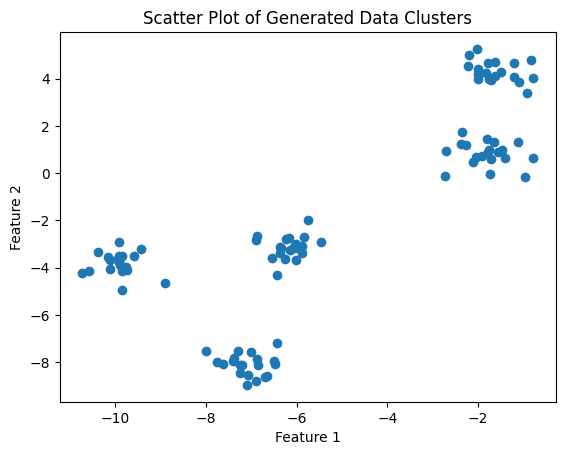

In [ ]:
# Import necessary libraries
from sklearn.datasets import make_blobs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate a random dataset with blob-like clusters
# n_samples: total number of data points
# n_features: number of features for each data point
# centers: number of clusters to generate
# cluster_std: standard deviation of the clusters, controls the spread of each cluster
# random_state: seed for reproducibility
dataset, classes = make_blobs(n_samples=100, n_features=2, centers=5, cluster_std=0.5, random_state=1)

# Create a DataFrame with the generated data
df = pd.DataFrame(dataset, columns=['Feature 1', 'Feature 2'])

# Display the first few rows of the DataFrame to understand the data structure
print(df)

# Plot the data points in a scatter plot
plt.scatter(df['Feature 1'], df['Feature 2'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot of Generated Data Clusters')
plt.show()

## K-means from scratch

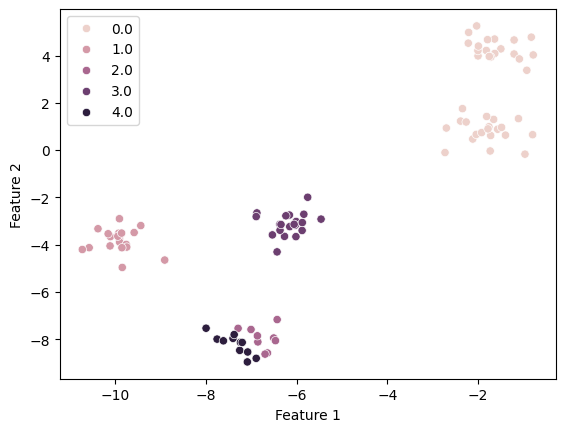

In [ ]:
import numpy as np

# Function to perform K-means clustering from scratch
def KMeans_from_scratch(input=None, clusters=3, tolerance=1e-3, max_iterations=10):
    num_samples = input.shape[0]
    centroids = []
    sample_clusters = np.zeros(num_samples)

    # Initialize random samples as initial centroids
    for i in range(clusters):
        random_sample_number = np.random.randint(num_samples)
        while random_sample_number not in centroids:
          # random_sample_number = np.random.randint(num_samples)
          centroids.append(random_sample_number)

    # Convert centroid indices to actual data points
    for i in range(len(centroids)):
        centroids[i] = input[centroids[i]]
    centroids = np.array(centroids)

    # K-means algorithm
    iteration = 0
    prev_centroids = np.zeros_like(centroids)

    # Run until convergence or maximum iterations
    while (iteration < max_iterations) and (np.linalg.norm(centroids - prev_centroids) > tolerance):
        prev_centroids = centroids.copy()

        # Assign each sample to the closest centroid
        for i in range(num_samples):
            for j in range(clusters):
                if j == 0:
                    least_distance = np.linalg.norm(input[i] - centroids[j])
                    sample_clusters[i] = j
                else:
                    distance = np.linalg.norm(input[i] - centroids[j])
                    if distance < least_distance:
                        least_distance = distance
                        sample_clusters[i] = j

        # Update centroids by calculating the mean of assigned samples
        for i in range(clusters):
            sum = 0.0
            num = 0
            for j in range(num_samples):
                if sample_clusters[j] == i:
                    sum += input[j]
                    num += 1
            centroids[i] = sum / num
        iteration += 1

    return centroids

# Run the K-means algorithm
centroids = KMeans_from_scratch(np.array(df), clusters=5)

# Function to assign samples to the closest centroid
def assign_clusters(input=None, centroids=None):
    num_samples = input.shape[0]
    clusters = centroids.shape[0]
    sample_clusters = np.zeros(num_samples)

    for i in range(num_samples):
        for j in range(clusters):
            if j == 0:
                least_distance = np.linalg.norm(input[i] - centroids[j])
                sample_clusters[i] = j
            else:
                distance = np.linalg.norm(input[i] - centroids[j])
                if distance < least_distance:
                    least_distance = distance
                    sample_clusters[i] = j

    return sample_clusters

# Assign clusters to samples based on final centroids
sample_clusters = assign_clusters(np.array(df), centroids)

# Plot clusters with Seaborn
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue=sample_clusters)
plt.show()

## Evaluation Metrics from Scratch

In [ ]:
import numpy as np
from itertools import combinations
from math import comb

# -----------------------------------------------------------
# Rand Index (RI)
# -----------------------------------------------------------
def custom_rand_index(labels_true, labels_pred):
    """Compute Rand Index from scratch."""
    n = len(labels_true)
    tp_tn = 0  # pairs that are either in same cluster in both or different in both
    total_pairs = comb(n, 2)

    for i, j in combinations(range(n), 2):
        same_true = (labels_true[i] == labels_true[j])
        same_pred = (labels_pred[i] == labels_pred[j])
        if same_true == same_pred:
            tp_tn += 1

    return tp_tn / total_pairs


# -----------------------------------------------------------
# Adjusted Rand Index (ARI)
# -----------------------------------------------------------
def custom_adjusted_rand_index(labels_true, labels_pred):
    """Compute Adjusted Rand Index from scratch."""
    labels_true = np.array(labels_true)
    labels_pred = np.array(labels_pred)
    n = len(labels_true)

    # Build contingency table
    classes, class_idx = np.unique(labels_true, return_inverse=True)
    clusters, cluster_idx = np.unique(labels_pred, return_inverse=True)
    n_classes = classes.size
    n_clusters = clusters.size

    contingency = np.zeros((n_classes, n_clusters), dtype=int) # num classes x num_clusters
    for i in range(n): #sample id
        contingency[class_idx[i], cluster_idx[i]] += 1

    sum_comb_c = sum(comb(n_ij, 2) for n_ij in contingency.flatten() if n_ij >= 2)
    sum_comb_rows = sum(comb(n_i, 2) for n_i in contingency.sum(axis=1) if n_i >= 2)
    sum_comb_cols = sum(comb(n_j, 2) for n_j in contingency.sum(axis=0) if n_j >= 2)
    total_pairs = comb(n, 2)

    numerator = sum_comb_c - (sum_comb_rows * sum_comb_cols) / total_pairs
    denominator = 0.5 * (sum_comb_rows + sum_comb_cols) - (sum_comb_rows * sum_comb_cols) / total_pairs

    return numerator / denominator if denominator != 0 else 0.0


# -----------------------------------------------------------
# Silhouette Score (SS)
# -----------------------------------------------------------
def custom_silhouette_score(X, labels):
    """Compute mean silhouette score from scratch (Euclidean distance)."""
    X = np.array(X)
    labels = np.array(labels)
    n = len(X)
    unique_labels = np.unique(labels)

    # Precompute pairwise distances
    dist_matrix = np.linalg.norm(X[:, np.newaxis] - X, axis=2)

    s_values = []
    for i in range(n):
        same_cluster = (labels == labels[i])
        other_clusters = unique_labels[unique_labels != labels[i]]

        # a(i): mean intra-cluster distance
        a = np.mean(dist_matrix[i, same_cluster & (np.arange(n) != i)]) if np.sum(same_cluster) > 1 else 0

        # b(i): mean nearest-cluster distance
        b = np.min([
            np.mean(dist_matrix[i, labels == c]) for c in other_clusters
        ]) if len(other_clusters) > 0 else 0

        s = (b - a) / max(a, b) if max(a, b) != 0 else 0
        s_values.append(s)

    return np.mean(s_values)

In [ ]:
print("Rand Index (scratch):", custom_rand_index(classes, sample_clusters))
print("Adjusted Rand Index (scratch):", custom_adjusted_rand_index(classes, sample_clusters))
print("Silhouette Score (scratch):", custom_silhouette_score(np.array(df), sample_clusters))


Rand Index (scratch): 0.8991919191919192
Adjusted Rand Index (scratch): 0.710021659886946
Silhouette Score (scratch): 0.6430243787311763


In [ ]:
from sklearn.metrics import silhouette_score, rand_score ,adjusted_rand_score
#Evaluate clusters - silhouette and adjusted rand index
sil_score_scratch = silhouette_score(np.array(df), sample_clusters)
ri_scratch = rand_score(classes, sample_clusters)
ari_scratch = adjusted_rand_score(classes, sample_clusters)
print(f'Silhouette Score (from scratch): {sil_score_scratch:.4f}')
print(f'Rand Score (from scratch): {ri_scratch:.4f}')
print(f'Adjusted Rand Index (from scratch): {ari_scratch:.4f}')

Silhouette Score (from scratch): 0.6430
Rand Score (from scratch): 0.8992
Adjusted Rand Index (from scratch): 0.7100


## K-means in sklearn and centroid visualization
Playground 1 [link text](https://hckr.pl/k-means-visualization)

Playground 2 [link text](https://www.naftaliharris.com/blog/visualizing-k-means-clustering)

Time taken: 0.044956207275390625


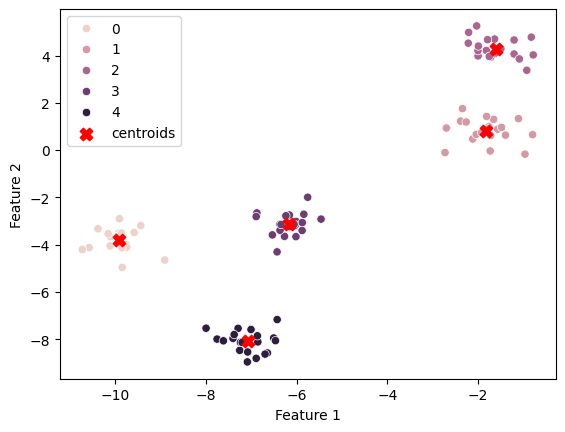

In [ ]:
from sklearn.cluster import KMeans
import time

# Initialize KMeans clustering with 5 clusters and random centroid initialization
kmeans = KMeans(n_clusters=5, init='random', random_state=1)

# Record the starting time before fitting the model
starting_time = time.time()
kmeans.fit(df)  # Fit the KMeans model on the dataset
ending_time = time.time()  # Record the ending time after fitting

# Calculate and print the time taken to fit the model
print("Time taken: " + str(ending_time - starting_time))

# Plot the clustered data
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue=kmeans.labels_)
# Plot the cluster centroids with a distinct marker
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="X", c="r", s=80, label="centroids")
plt.legend()
plt.show()

## Elbow method, using Within Clusters Sum of Squares (WCSS)

1 2846.5300716544302
2 603.7111973512078
3 305.83525006332206
4 160.9422029506187
5 39.440748066083216
6 36.19341315957499
7 33.70100353566085
8 30.707377408568853
9 27.616883649768607
10 26.837416994282886


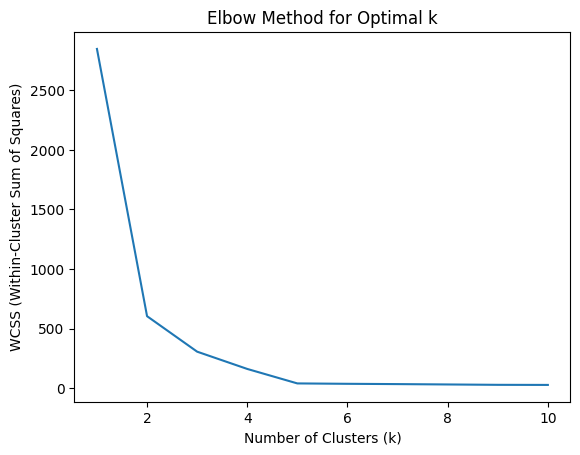

In [ ]:
def elbow(input, k_values=[1, 2, 3, 4, 5, 6, 7, 8, 9]):
    wcss_values = []  # List to store within-cluster sum of squares (WCSS) for each k

    # Iterate over different values of k (number of clusters)
    for k_value in k_values:
        sum = 0.0
        # Fit KMeans with the current number of clusters
        kmeans = KMeans(n_clusters=k_value, init='random', random_state=1).fit(input)

        # Calculate WCSS by summing squared distances of each point to its cluster center
        for i in range(k_value):
            for j in range(input.shape[0]):
                if kmeans.labels_[j] == i:
                    sum += np.linalg.norm(input[j] - kmeans.cluster_centers_[i]) ** 2.0
        wcss_values.append(sum)  # Append WCSS for the current k to the list

    return wcss_values

# Define the range of k values to test for optimal clustering
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Compute WCSS for each k value using the elbow function
wcss_values = elbow(np.array(df), k_values=k_values)

# Print WCSS values for each k to analyze the results
for i in range(len(wcss_values)):
    print(k_values[i], wcss_values[i])

# Plot the elbow curve to visualize the optimal k value
plt.plot(k_values, wcss_values)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal k")
plt.show()

## Hierarchical Agglomerative Clustering from Scratch

Time taken: 7.748852491378784


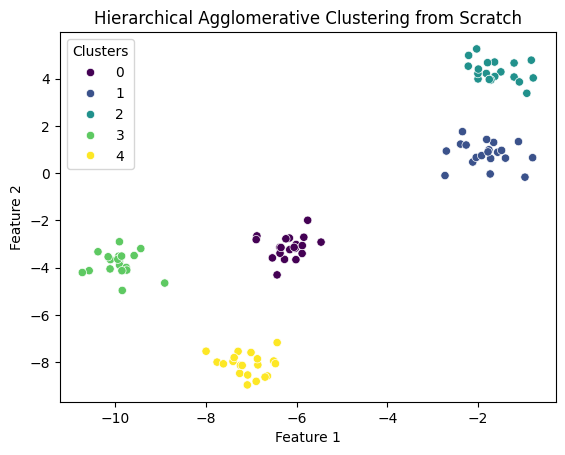

In [ ]:
import time
from scipy.spatial.distance import cdist

# Custom Euclidean distance function
def euclidean_distance(point1, point2):
    return np.linalg.norm(point1 - point2)

# Complete linkage function: maximum distance between all pairs of points in two clusters
def complete_linkage(cluster1, cluster2):
    distances = cdist(cluster1, cluster2, metric='euclidean')
    return np.max(distances)


def hac_from_scratch(data, num_clusters):
    clusters = [[i] for i in range(len(data))]  # Each data point starts as its own cluster
    cluster_labels = np.arange(len(data))  # Initialize cluster labels

    # Continue until the target number of clusters is reached
    while len(clusters) > num_clusters:
        min_distance = float('inf')
        merge_clusters = (None, None)

        # Find the two closest clusters
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                cluster1_points = data[clusters[i]]
                cluster2_points = data[clusters[j]]
                distance = complete_linkage(cluster1_points, cluster2_points)
                if distance < min_distance:
                    min_distance = distance
                    merge_clusters = (i, j)

        # Merge the two closest clusters
        cluster1, cluster2 = merge_clusters
        clusters[cluster1].extend(clusters[cluster2])
        del clusters[cluster2]  # Remove the merged cluster

        # Assign a new contiguous label
        new_label = len(clusters)  # This will be the index of the merged cluster in the list
        for idx in clusters[cluster1]:
            cluster_labels[idx] = new_label

    # Final adjustment to ensure labels are contiguous
    unique_labels = np.unique(cluster_labels)
    for new_label, old_label in enumerate(unique_labels):
        cluster_labels[cluster_labels == old_label] = new_label

    return cluster_labels


# Dataset generation
data = np.array(df)  # Convert the DataFrame to a numpy array
num_clusters = 5

# Measure the time taken for clustering
starting_time = time.time()
labels = hac_from_scratch(data, num_clusters)
ending_time = time.time()

# Display time taken
print("Time taken: " + str(ending_time - starting_time))

# Add the cluster labels to the DataFrame
df['Cluster'] = labels

# Plotting the clusters with seaborn for similar visualization
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Cluster", palette="viridis")
plt.legend(title="Clusters")
plt.title("Hierarchical Agglomerative Clustering from Scratch")
plt.show()

In [ ]:
sil_score_scratch = silhouette_score(np.array(df), labels)
ri_scratch = rand_score(classes, labels)
ari_scratch = adjusted_rand_score(classes, labels)
print(f'Silhouette Score (from scratch): {sil_score_scratch:.4f}')
print(f'Rand Score (from scratch): {ri_scratch:.4f}')
print(f'Adjusted Rand Index (from scratch): {ari_scratch:.4f}')

Silhouette Score (from scratch): 0.8136
Rand Score (from scratch): 1.0000
Adjusted Rand Index (from scratch): 1.0000


## Sklearn implementation of Agglomerative Clustering

Time taken: 0.004725456237792969


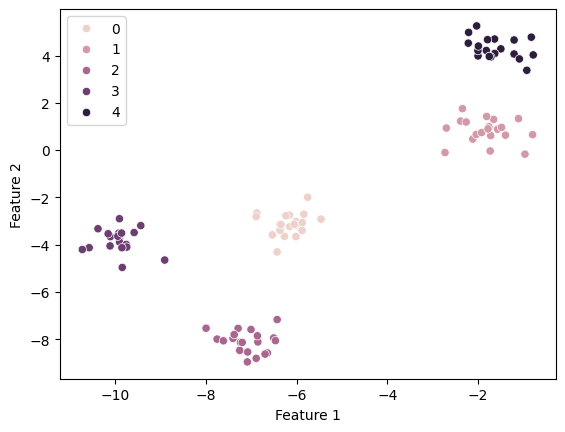

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Initialize the Agglomerative Clustering model with 5 clusters, using Euclidean distance and complete linkage
clustering_model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='complete')

# Record the start time, fit the model, and record the end time to measure performance
starting_time = time.time()
clustering_model.fit(df)
ending_time = time.time()

# Print the time taken to perform clustering
print("Time taken: " + str(ending_time - starting_time))

# Visualize the clustered data points
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue=clustering_model.labels_)
plt.legend()
plt.show()

## Dendogram visualization

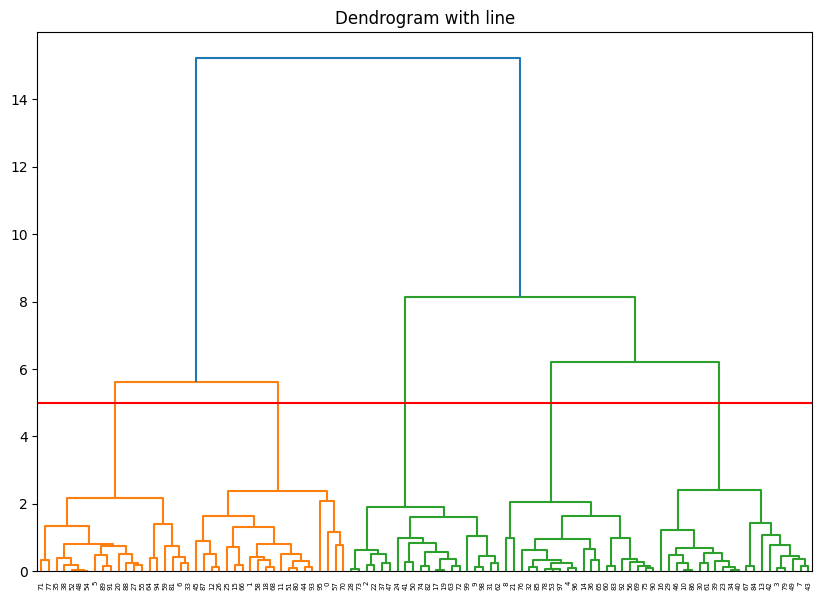

In [ ]:
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

# Set up the figure size and title for the dendrogram plot
plt.figure(figsize=(10, 7))
plt.title("Dendrogram with line")

# Perform hierarchical clustering using the 'complete' linkage method and 'euclidean' distance metric
clusters = shc.linkage(df, method='complete', metric="euclidean")

# Plot the dendrogram for visualizing cluster hierarchy
shc.dendrogram(clusters)

# Draw a horizontal line at a specified height (y=73) to indicate the cluster cutoff point
plt.axhline(y=5, color='r', linestyle='-')
plt.show()

## Sklearn and Scratch implementation comparison of HAC

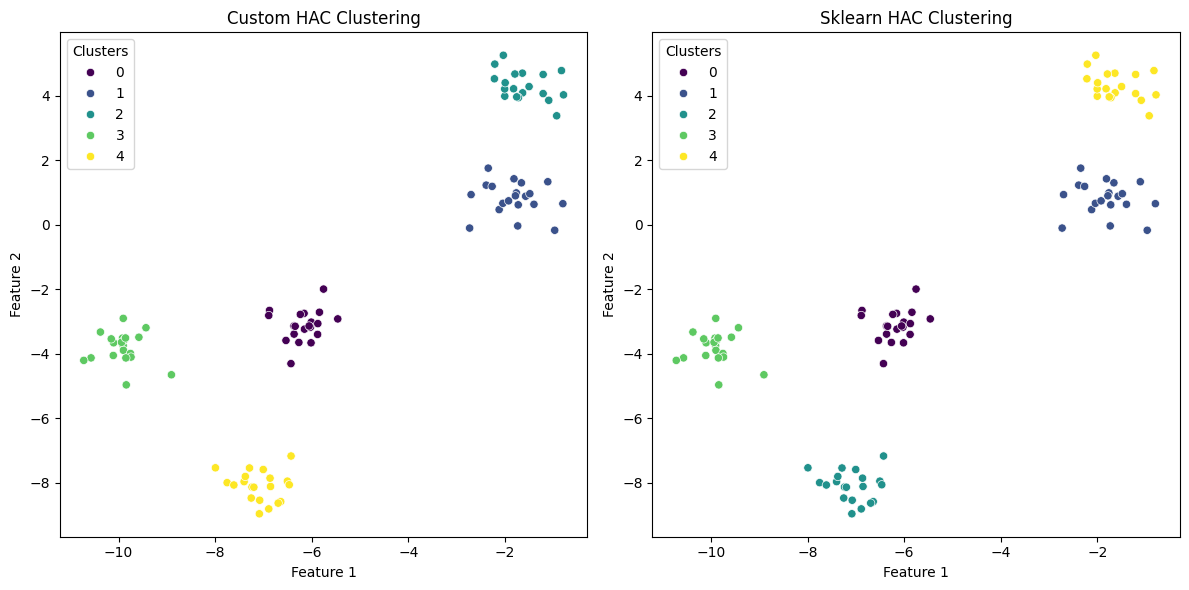

In [ ]:
# Visualization of clustering results side by side
plt.figure(figsize=(12, 6))

# Custom Implementation Visualization
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue= "Cluster", palette="viridis", legend="full")
plt.title("Custom HAC Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Clusters")

# Sklearn Implementation Visualization
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue=clustering_model.labels_, palette="viridis", legend="full")
plt.title("Sklearn HAC Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Clusters")

plt.tight_layout()
plt.show()

## **Assignment 10**

### <font color='orange'> Task - 1: Data Loading and Preprocessing (2 Marks) </font>:
1. Load the [UCI Seeds dataset](https://archive.ics.uci.edu/dataset/236/seeds).
2. Check for missing values and duplicate rows in the dataset.
3. Handle any missing or duplicate data appropriately.

Marks Distribution:

1. Loading and displaying dataset: 1 mark
2. Checking and handling missing/duplicate data: 1 mark

### <font color='orange'> Task - 2: K-Means Clustering Implementation from Scratch (6 Marks) </font>:

1. Implement the K-Means algorithm from scratch.
2. Use K-Means++ initialization to select initial centroids.
3. Perform clustering with 3 clusters.
4. Display the final cluster centroids and the number of samples in each cluster.

Marks Distribution:

1. Correct implementation of K-Means algorithm logic: 3 marks
2. Proper use of K-Means++ initialization: 2 marks
3. Display and interpretation of results: 1 mark

### <font color='orange'> Task - 3: Cluster Evaluation (2 Marks) </font>:

1. Evaluate the silhouette and Rand scores using scikit-learn functions.

Marks Distribution:

1. Correct computation of silhouette (1 mark) and Rand (1 mark) scores: 2 marks


### <font color='orange'> Task - 4: Ground Truth Comparison and Label Assignment (4 Marks) </font>:

1. Using the ground truth labels available in the dataset, create a table showing how many samples of each true class fall into each cluster.
2. For each cluster, assign the majority class label to that cluster.
3. Compute accuracy, precision, and recall based on this assignment.

Marks Distribution:

1. Correct tabular comparison of clusters vs. true labels: 2 mark
2. Correct label assignment and metric computation: 2 marks

### <font color='orange'> Task - 5: Clustering using scikit-learn K-Means (3 Marks) </font>:

1. Perform clustering on the same dataset using scikit-learn’s KMeans with K-Means++ initialization and 3 clusters.
2. Compute silhouette score and Rand index.
3. Compare the results with your from-scratch implementation.

Marks Distribution:

1. Correct implementation and metric computation: 2 marks
2. Results Comparison: 1 mark

### <font color='orange'> Task - 6: Label Assignment and Evaluation for scikit-learn Clustering (3 Marks) </font>:

1. Repeat the majority class label assignment procedure for the clusters obtained from scikit-learn.
2. Compute accuracy, precision, and recall.
3. Compare these values with those from the from-scratch implementation.
4. Visualize the clusters (from-scratch and scikit-learn) using a 2D scatter plot with different colors for each cluster and mark the centroids.

Marks Distribution:

1. Correct label assignment and metric computation: 1 mark
2. Proper comparison and discussion: 1 mark
3. Visualization: 1 mark